In [1]:
import json
import datetime
from IPython.display import Markdown, display

from openagri_benchmark.postprocessing.use_cases import (
    UseCaseA
)

from openagri_benchmark.postprocessing.utils import (
    plot_use_case_processing_energy_by_step,
    plot_use_case_total_energy_by_setup
)

In [2]:
use_case_a_low_cloud_results = UseCaseA(
    base_workload='low',
    deployment_setup='cloud', 
    # init_datetime=init, end_datatime=end, 
    tasks_profiling_id='test_profile'
).run()

In [3]:
display(Markdown(UseCaseA.get_markdown_of_usecase_steps(use_case_a_low_cloud_results)))


# UseCaseA

Use Case A: Integrated crop-protection and pesticide use reporting for vineyards (Farm Calendar, Pest and Disease Management, Weather Service)

A micro SME with expertise in ICT  is located in a rural area in Greece and wants to get into the smart agriculture business. They decided to collaborate with local farm advisors and to offer digital services including recording of farm management practices, decision support on crop protection and reporting about pesticides use. They have a new contract with a local farmers association cultivating vineyards.
We consider a small use-case, with a low workload scenario, where the farmers association has 2 members/farmers and each farmer manages from 1-5 parcels. Each parcel covers an area from 1-5 hectares.

For grapevines, the “cultivation period” usually means the period from budbreak to harvest. In most wine-grape and table-grape regions, it lasts about: 150–200 days. In Mediterranean climates, grapevines often start active growth around March–April and are harvested around August–September, depending on variety, altitude, irrigation, and intended use.

The initial date is set for the last day of February (one day to setup all the services and register parcels, etc..)
and the final date is set for first day of November, after the harvest and reporting.

## 1: 1Day-Feb

| Service | Task | Workload | Repetition | Description |
|---|---|---|---|---|
| farmcalendar | register_farm | low | 2 | Register one farm per farmer account. |
| farmcalendar | register_parcel | low | 10 | Register 5 parcel per farm. |
| farmcalendar | register_crop | low | 10 | Register some grapevine crops for each parcel. |
| farmcalendar | register_activity_type | low | 6 | Creating new generic activity types specific for the use case. |
| farmcalendar | filter_parcels | low | 40 | Farmer selects a parcel from their list to view its details. |
| farmcalendar | monthly_activities | low | 20 | Farmer opens the monthly calendar view for a parcel. |
| farmcalendar | get_activity | low | 40 | Farmer opens detail view of a specific calendar activity. |

## 2: March-April

| Service | Task | Workload | Repetition | Description |
|---|---|---|---|---|
| weather | get_daily_forecast | low | 310 | Daily weather forecast per parcel for budbreak and disease-risk context. |
| pestanddisease | calculate_gdd | low | 310 | Daily growing-degree-day calculation per parcel to track budbreak progression. |
| pestanddisease | calculate_risk | low | 310 | Daily pest/disease infestation risk query per parcel for first disease monitoring. |
| farmcalendar | register_obs | low | 10 | Record budbreak monitoring observation on each parcel. |
| farmcalendar | register_gen_activity | low | 10 | Record realised weed control activity on each parcel. |
| farmcalendar | register_obs | low | 10 | Record first disease monitoring observation on each parcel. |
| farmcalendar | filter_parcels | low | 1240 | Farmer selects a parcel from their list to view its details. |
| farmcalendar | monthly_activities | low | 620 | Farmer opens the monthly calendar view for a parcel. |
| farmcalendar | get_activity | low | 1240 | Farmer opens detail view of a specific calendar activity. |

## 3: April-May

| Service | Task | Workload | Repetition | Description |
|---|---|---|---|---|
| weather | get_daily_forecast | low | 300 | Daily weather forecast per parcel to guide canopy management timing. |
| pestanddisease | calculate_gdd | low | 300 | Daily growing-degree-day calculation per parcel to track vine development. |
| pestanddisease | calculate_risk | low | 300 | Daily pest/disease infestation risk query per parcel during early canopy growth. |
| farmcalendar | register_obs | low | 80 | Record shoot development / phenology stage observation on each parcel during active growth. |
| farmcalendar | register_obs | low | 10 | Record early canopy assessment observation on each parcel (density, vigor, light penetration). |
| farmcalendar | register_obs | low | 10 | Record any early disease/pest symptoms noticed during manual canopy work on each parcel. |
| farmcalendar | register_gen_activity | low | 10 | Record realised shoot thinning activity on each parcel. |
| farmcalendar | register_gen_activity | low | 20 | Record realised sucker removal activity on each parcel. |
| farmcalendar | register_gen_activity | low | 30 | Record realised early canopy management activity on each parcel. |
| farmcalendar | filter_parcels | low | 1200 | Farmer selects a parcel from their list to view its details. |
| farmcalendar | monthly_activities | low | 600 | Farmer opens the monthly calendar view for a parcel. |
| farmcalendar | get_activity | low | 1200 | Farmer opens detail view of a specific calendar activity. |

## 4: May-June

| Service | Task | Workload | Repetition | Description |
|---|---|---|---|---|
| weather | get_daily_forecast | low | 310 | Daily weather forecast per parcel for flowering and disease-protection timing. |
| pestanddisease | calculate_gdd | low | 310 | Daily growing-degree-day calculation per parcel to track flowering progression. |
| pestanddisease | calculate_risk | low | 310 | Daily pest/disease infestation risk query per parcel during flowering. |
| farmcalendar | register_gen_activity | low | 20 | Record realised shoot positioning activity on each parcel. |
| farmcalendar | register_gen_activity | low | 30 | Record realised disease-protection (plant protection product) applications on each parcel. |
| farmcalendar | register_obs | low | 200 | Record flowering monitoring observation on each parcel (stage, uniformity, bloom). |
| farmcalendar | register_obs | low | 10 | Record disease/pest symptoms noticed during shoot positioning and disease-protection rounds. |
| farmcalendar | filter_parcels | low | 1240 | Farmer selects a parcel from their list to view its details. |
| farmcalendar | monthly_activities | low | 620 | Farmer opens the monthly calendar view for a parcel. |
| farmcalendar | get_activity | low | 1240 | Farmer opens detail view of a specific calendar activity. |

## 5: June-July

| Service | Task | Workload | Repetition | Description |
|---|---|---|---|---|
| weather | get_daily_forecast | low | 300 | Daily weather forecast per parcel for irrigation and canopy-management decisions. |
| pestanddisease | calculate_gdd | low | 300 | Daily growing-degree-day calculation per parcel to track fruit development. |
| pestanddisease | calculate_risk | low | 300 | Daily pest/disease infestation risk query per parcel during fruit set and cluster development. |
| farmcalendar | register_gen_activity | low | 10 | Record realised leaf removal activity on each parcel. |
| farmcalendar | register_gen_activity | low | 10 | Record realised cluster thinning activity on each parcel. |
| farmcalendar | register_gen_activity | low | 40 | Record realised irrigation management activity on each parcel (repeated through the period). |
| farmcalendar | register_obs | low | 10 | Record fruit set assessment observation on each parcel. |
| farmcalendar | register_obs | low | 10 | Record any disease/pest symptoms noticed during fruit set and cluster work on each parcel. |
| farmcalendar | filter_parcels | low | 1200 | Farmer selects a parcel from their list to view its details. |
| farmcalendar | monthly_activities | low | 600 | Farmer opens the monthly calendar view for a parcel. |
| farmcalendar | get_activity | low | 1200 | Farmer opens detail view of a specific calendar activity. |

## 6: July-August

| Service | Task | Workload | Repetition | Description |
|---|---|---|---|---|
| weather | get_daily_forecast | low | 310 | Daily weather forecast per parcel for canopy trimming and pest/disease control timing. |
| pestanddisease | calculate_gdd | low | 310 | Daily growing-degree-day calculation per parcel to track veraison progression. |
| pestanddisease | calculate_risk | low | 310 | Daily pest/disease infestation risk query per parcel during veraison. |
| farmcalendar | register_gen_activity | low | 20 | Record realised canopy trimming activity on each parcel. |
| farmcalendar | register_gen_activity | low | 30 | Record realised pest and disease control (plant protection product) applications on each parcel. |
| farmcalendar | register_obs | low | 150 | Record veraison monitoring observation on each parcel (colour change, ripening stage). |
| farmcalendar | register_obs | low | 10 | Record pest/disease symptoms noticed during canopy trimming and control rounds on each parcel. |
| farmcalendar | filter_parcels | low | 1240 | Farmer selects a parcel from their list to view its details. |
| farmcalendar | monthly_activities | low | 620 | Farmer opens the monthly calendar view for a parcel. |
| farmcalendar | get_activity | low | 1240 | Farmer opens detail view of a specific calendar activity. |

## 7: August-September

| Service | Task | Workload | Repetition | Description |
|---|---|---|---|---|
| weather | get_daily_forecast | low | 310 | Daily weather forecast per parcel for final irrigation and harvest-planning decisions. |
| pestanddisease | calculate_gdd | low | 310 | Daily growing-degree-day calculation per parcel to track ripening progression. |
| pestanddisease | calculate_risk | low | 310 | Daily pest/disease infestation risk query per parcel approaching harvest. |
| farmcalendar | register_gen_activity | low | 20 | Record realised final irrigation decision activity on each parcel. |
| farmcalendar | register_gen_activity | low | 10 | Record realised harvest planning activity on each parcel. |
| farmcalendar | register_obs | low | 200 | Record ripeness sampling observation on each parcel (sugar, acidity, phenolics). |
| farmcalendar | register_obs | low | 10 | Record final disease/pest symptoms check on each parcel before harvest. |
| farmcalendar | filter_parcels | low | 1240 | Farmer selects a parcel from their list to view its details. |
| farmcalendar | monthly_activities | low | 620 | Farmer opens the monthly calendar view for a parcel. |
| farmcalendar | get_activity | low | 1240 | Farmer opens detail view of a specific calendar activity. |

## 8: September-October

| Service | Task | Workload | Repetition | Description |
|---|---|---|---|---|
| weather | get_daily_forecast | low | 300 | Daily weather forecast per parcel to finalise harvest timing. |
| farmcalendar | register_gen_activity | low | 10 | Record realised harvest activity on each parcel. |
| farmcalendar | register_obs | low | 10 | Record final pre-harvest observation (ripeness confirmation, yield estimate) on each parcel. |
| reporting | standalone_report | low | 10 | Generate per-parcel report of all farm practices applied over the cultivation period. |
| reporting | pesticides_report | low | 10 | Generate per-parcel annual pesticide-use report according to legislation. |
| farmcalendar | filter_parcels | low | 1200 | Farmer selects a parcel from their list to view its details. |
| farmcalendar | monthly_activities | low | 600 | Farmer opens the monthly calendar view for a parcel. |
| farmcalendar | get_activity | low | 1200 | Farmer opens detail view of a specific calendar activity. |



In [4]:
# print(json.dumps(use_case_a_low_cloud_results, indent=4))

## mock edge results as 8% of cloud energy  (replace later with actual edge results)

In [5]:

use_case_1_results = {
    'cloud-low': use_case_a_low_cloud_results
}
import copy


# Deep copy so we don't mutate the original
use_case_a_low_edge_mocked = copy.deepcopy(use_case_a_low_cloud_results)

# Scale every step's energy by 0.08 (8% of cloud)
for step in use_case_a_low_edge_mocked["steps"].values():
    step["energy"] *= 0.08

# Recompute the totals that depend on energy (proc_energy, total_energy)
use_case_a_low_edge_mocked["totals"]["proc_energy"] *= 0.08
use_case_a_low_edge_mocked["totals"]["iddle_energy"] *= 0.08
use_case_a_low_edge_mocked["totals"]["total_energy"] = (
    use_case_a_low_edge_mocked["totals"]["proc_energy"]
    + use_case_a_low_edge_mocked["totals"]["iddle_energy"]
)

use_case_1_results = {
    "cloud": use_case_a_low_cloud_results,
    "edge":  use_case_a_low_edge_mocked,
}

## Processing Energy UseCase

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Processing Energy Consumption Throughout Use Case A'}, ylabel='Processing Energy (Wh)'>)

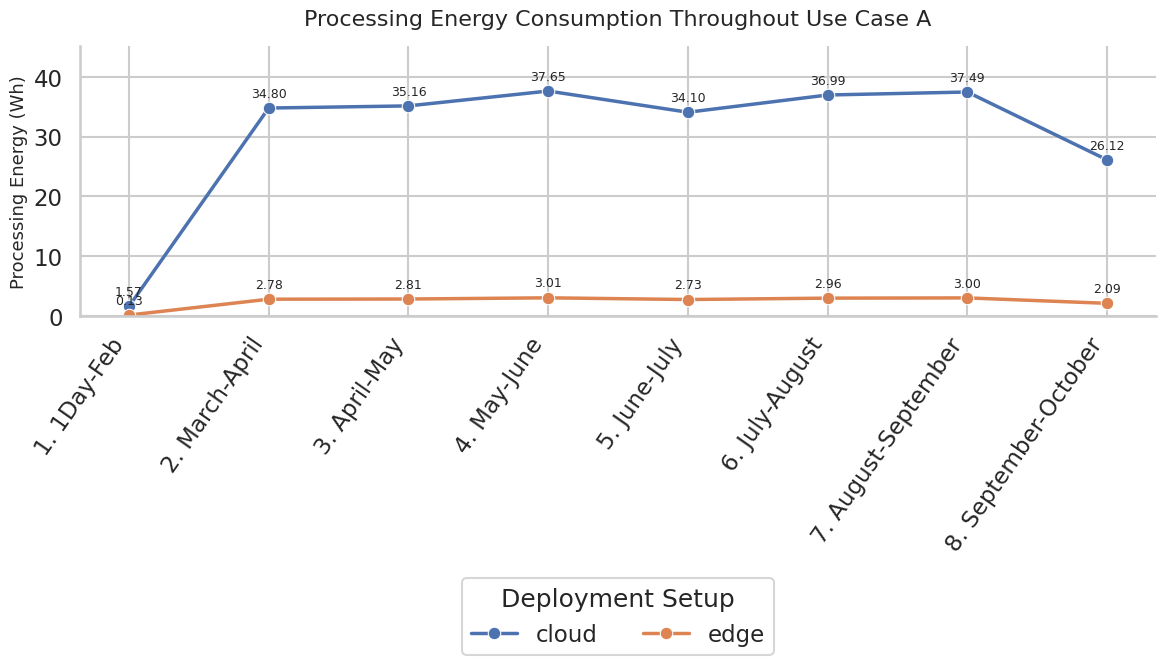

In [8]:
plot_use_case_processing_energy_by_step(use_case_1_results, use_case='A') 

## Total Energy for UseCase

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Total Energy Consumption per Deployment Setup - Use Case A'}, xlabel='Deployment Setup', ylabel='Total Energy (kWh)'>)

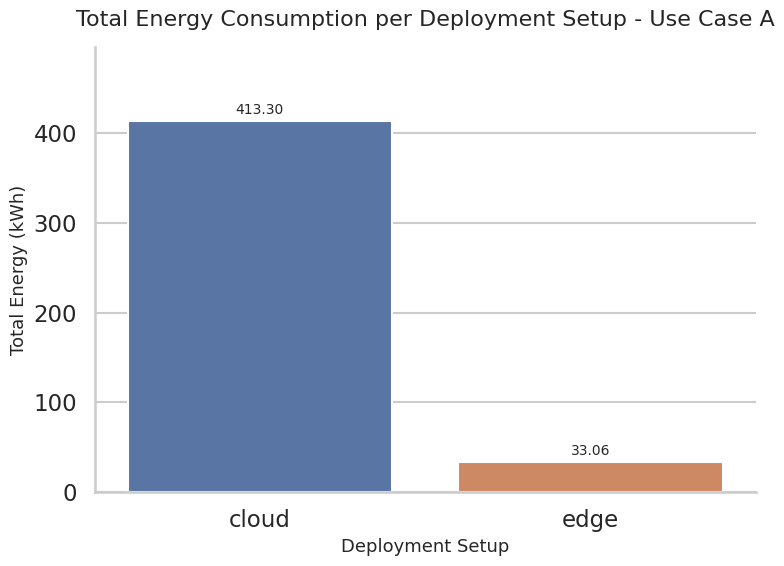

In [9]:
plot_use_case_total_energy_by_setup(use_case_1_results, use_case="A")